In [1]:
import numpy as np 
import scipy as sp
from brian2 import *
from matplotlib import rcParams, font_manager

from lmfit import Parameters, Minimizer
from scipy import stats

INFO       Cache size for target 'cython': 6462 MB.
You can call clear_cache('cython') to delete all files from the cache or manually delete files in the 'C:\Users\yawnt\.cython\brian_extensions' directory. [brian2]


In [2]:
#Figure Parameters 
rcParams['figure.figsize'] = (4,4) #figure size in inches
rcParams['font.size'] = 24
rcParams['pdf.fonttype'] = 42
rcParams['axes.linewidth'] = 2 #thickness of the border
rcParams['xtick.major.width'] = rcParams['axes.linewidth'] 
rcParams['ytick.major.width'] = rcParams['axes.linewidth']
rcParams['axes.spines.right'] = False #hides right border
rcParams['axes.spines.top'] = False #hides top
rcParams['legend.frameon'] = False #hides box around the legend
rcParams['legend.fontsize'] = 18 #font size in pt
rcParams['axes.labelsize'] = 32 
rcParams['xtick.labelsize'] = 24
rcParams['ytick.labelsize'] = rcParams['xtick.labelsize']
rcParams['lines.linewidth'] = 3
rcParams['xtick.major.size'] = 5
rcParams['lines.markersize'] = 8
rcParams['ytick.major.size'] = rcParams['xtick.major.size'] 
rcParams['lines.color'] = 'black'
rcParams['axes.prop_cycle'] = plt.cycler(color=['black', 'red', 'blue', 'green', 'purple', 'brown'])


In [3]:
#Plotting Functions
def f_I(current_values, FR_arr): 
    plt.figure()
    plt.plot(current_values, FR_arr) 
    plt.xlabel("Current (uA)")
    plt.ylabel("Firing Rate (Hz)")
    plt.title("f-I Curve")
    plt.show()
    return 

def plot_current_adapt(current_values, HW_arr, dAdap_arr, rheobase_ind): 
    rheobase = current_values[rheobase_ind]
    plt.figure()
    plt.plot(current_values[rheobase_ind:]/rheobase, HW_arr[rheobase_ind:])
    plt.xlabel("Current[*rheobase]")
    plt.ylabel("Spike Width (ms)")
    plt.xlim(1, None)
    plt.show()
    
    plt.figure()
    plt.plot(current_values[rheobase_ind:]/rheobase, dAdap_arr[rheobase_ind:])
    plt.xlabel("Current[*rheobase]")
    plt.ylabel("Degree of Adaptation")
    plt.xlim(1, None)
    plt.show()
    
    print("Half Width: ", HW_arr[rheobase_ind*1.5])
    print("Degree of Adaptation: ", dAdap_arr[rheobase_ind*1.5]) 
    return 

def compute_fI_curve(state_monitor, inj_current, start_end): 
    time = state_monitor.t / ms
    start, end = start_end[0], start_end[1]
    start_idx = np.where(time >= start)[0][0]  
    end_idx = np.where(time <= end)[0][-1]  
    duration = (time[end_idx] - time[start_idx]) / 1000  
    
    currents, firing_rates = [], []
    
    for neuron_idx in range(len(inj_current)):
        # Get current value for this neuron
        current_val = inj_current[neuron_idx]
        currents.append(current_val)
        
        # Extract voltage for analysis window
        voltage = state_monitor[neuron_idx].v / mV  # Full voltage trace
        analysis_time = time
        
        sweep_vmax = np.max(voltage)
        sweep_vup = np.min((sweep_vmax, 20))
        sweep_vlow = np.max((-40, np.median(voltage)))
        sweep_vthr = np.max(((sweep_vup*0.8)+(sweep_vlow*0.2), 0))
        
        # Spike detection with adaptive threshold
        flag_spike = (voltage[:-1] < sweep_vthr) & (voltage[1:] >= sweep_vthr) & \
                    (analysis_time[:-1] >= time[start_idx]) & (analysis_time[:-1] <= time[end_idx])
        spikes = np.sum(flag_spike)
        firing_rates.append(spikes / duration)
    
    plt.figure()
    plt.plot(currents, firing_rates, 'bo-', linewidth=2, markersize=6)
    plt.xlabel('Injected Current (uA)')
    plt.ylabel('Firing Rate (Hz)')
    plt.title('F-I Curve')
    plt.grid(True, alpha=0.3)
    plt.show()
    return 

def plot_trace(state_monitor, i_neuron, inj_current, t_start=500,fname = ""): 
    # Define current attributes and their display names
    current_info = [
        ('Ina', 'Sodium'),
        ('Ik', 'Voltage Gated Potassium'),
        ('IL', 'Leak'),
        ('ICaL', 'Ca-L'),
        ('ICaT', 'Ca-T'),
        ('Iahp', 'Calcium dependent Potassium'),
        ('Iapp', 'Applied')
    ]
    
    # Plot voltage traces for all neurons
    plt.figure()
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    for idx, neuron_idx in enumerate(i_neuron):
        current_val = inj_current[idx] if isinstance(inj_current, list) else inj_current
        time_array = state_monitor.t/ms - t_start
        voltage_array = state_monitor[neuron_idx].v/mV
        
        mask = time_array < 1050
        time_filtered = time_array[mask]
        voltage_filtered = voltage_array[mask]
        
        plt.plot(time_filtered, voltage_filtered, label=f'{current_val} uA')
    
    plt.xticks(range(0, 1001, 500), range(0, 1001, 500))  
    plt.yticks([ -60, -20,  20])
    plt.xlim(-50, 1050)
    #plt.yticks([-80, -60, -40, -20, 0, 20])
    #plt.locator_params(axis = 'y', nbins = 6)   # Previous nbins=3
    plt.title("Voltage Traces")
    if len(i_neuron) > 1:
        plt.legend()
    if fname != "": 
        plt.savefig(fname + "_voltage.svg")
        plt.savefig(fname + "_voltage.jpg")

    plt.show()

    # Plot voltage traces for all neurons
    plt.figure()
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    for idx, neuron_idx in enumerate(i_neuron):
        current_val = inj_current[idx] if isinstance(inj_current, list) else inj_current
        time_array = state_monitor.t/ms - t_start
        voltage_array = state_monitor[neuron_idx].v/mV
        
        mask = time_array < 100
        time_filtered = time_array[mask]
        voltage_filtered = voltage_array[mask]
        
        plt.plot(time_filtered, voltage_filtered, label=f'{current_val} uA')
    
    plt.xticks(range(0, 101, 50), range(0, 101, 50))  
    plt.yticks([ -60, -20,  20])
    plt.xlim(-10, 100)
    #plt.yticks([-80, -60, -40, -20, 0, 20])
    #plt.locator_params(axis = 'y', nbins = 6)   # Previous nbins=3
    plt.title("Voltage Traces")
    if len(i_neuron) > 1:
        plt.legend()
    if fname != "": 
        plt.savefig(fname + "_voltageZoomin.svg")
        plt.savefig(fname + "_voltageZoomin.jpg")

    plt.show()

    
    # Plot calcium concentration for all neurons
    plt.figure()
    plt.xlabel("Time(ms)")
    plt.ylabel("Calcium concentration (uMolar)")
    for idx, neuron_idx in enumerate(i_neuron):
        current_val = inj_current[idx] if isinstance(inj_current, list) else inj_current
        plt.plot(state_monitor.t/ms - t_start, state_monitor[neuron_idx].Ca/umolar, label=f'{current_val} uA')
    plt.xticks(range(0, 1001, 250), range(0, 1001, 250))
    plt.title("Calcium Concentration")
    if len(i_neuron) > 1:
        plt.legend()
    if fname != "":
        plt.savefig(fname + "_calcium.svg")
        plt.savefig(fname + "_calcium.jpg")
    plt.show()
    
    # Plot each current type for all neurons
    '''
    for current_attr, current_name in current_info:
        plt.figure()
        plt.xlabel("Time (ms)")
        plt.ylabel(current_name + " current (uAamps)")
        
        for idx, neuron_idx in enumerate(i_neuron):
            current_val = inj_current[idx] if isinstance(inj_current, list) else inj_current
            current_data = getattr(state_monitor, current_attr)[neuron_idx]/amp
            plt.plot(state_monitor.t/ms  - t_start, current_data*10**6, label=f'{current_val} uA')
        
        plt.xticks(range(0, 1001, 250), range(0, 1001, 250))   
        plt.title(current_name + " Current")
        if len(i_neuron) > 1:
            plt.legend()
        if fname != "":
            plt.savefig(fname + f"_{current_name.replace(' ', '_').replace('-', '_').lower()}.svg")
            plt.savefig(fname + f"_{current_name.replace(' ', '_').replace('-', '_').lower()}.jpg")
        plt.show()
    '''
    print("IAHP Aat the start of injection: ", state_monitor[neuron_idx].Iahp[t_start-1])
    return

def plot_fit(e_info, ymax=150,xmin=-100,xmax=1100,fname = ""): 
    HW_info = e_info['HW_plot']
    AP_waveform = HW_info['APwaveform']
    dtstep = HW_info['dtstep']
    
    #Plot for the Half-Width
    plt.figure()
    for sweep in range(len(AP_waveform)): 
        plt.plot(np.arange(len(AP_waveform[sweep]))*dtstep, AP_waveform[sweep])
    plt.show()
    
    #Plot to show the adaptation
    dAdap_info = e_info['dAdap_plot']
    t_scatter = dAdap_info["t_scatter"]
    
    FI_scatter = dAdap_info["FI_scatter"]
    t_axis = np.linspace(t_scatter[0],t_scatter[-1],num=int((t_scatter[-1]-t_scatter[0])/0.01+1),endpoint=True)
    y_fit = dAdap_info["y_fit"]
    
    OB_info = e_info['OB_plot']
    y_de_fit = OB_info['fit_de']
    y_de_fitted = eval_fit(double_exp_func, y_de_fit.params ,t_axis)
    
    y_se_fit= OB_info['fit_se']
    Aad_de = y_se_fit.params['A2'].value           
    Kad_de = y_se_fit.params['k2'].value
    C_de = y_se_fit.params['C'].value
    
    eval_adap_rate = single_exp_func(t_axis, Aad_de, Kad_de, C_de)
                        
    plt.figure()
    plt.scatter(t_scatter, FI_scatter)
    plt.plot(t_axis, y_de_fitted, label = "Double Exp Fit")
    plt.plot(t_axis, eval_adap_rate, label = 'Single Exp Fit')
    plt.locator_params(axis = 'y', nbins = 3)
    plt.legend()
    plt.ylim([0, ymax])
    plt.xlim([xmin, xmax])


    if fname != "": 
        plt.savefig(fname + "_fittings.svg")
        plt.savefig(fname + "_fittings.jpg")
    plt.show()


    return 

# def plot_fit(e_info): 
#     HW_info = e_info['HW_plot']
#     AP_waveform = HW_info['APwaveform']
#     dtstep = HW_info['dtstep']
    
#     #Plot for the Half-Width
#     plt.figure()
#     for sweep in range(len(AP_waveform)): 
#         plt.plot(np.arange(len(AP_waveform[sweep]))*dtstep, AP_waveform[sweep])
#     plt.show()
    
#     #Plot to show the adaptation
#     dAdap_info = e_info['dAdap_plot']
#     t_scatter = dAdap_info["t_scatter"]
#     FI_scatter = dAdap_info["FI_scatter"]
#     t_axis = dAdap_info["t_axis"]
#     y_fit = dAdap_info["y_fit"]
    
#     OB_info = e_info['OB_plot']
#     y_de_fit = OB_info['fit_de']
#     y_de_fitted = eval_fit(double_exp_func, y_de_fit.params ,t_axis)
    
#     Aad_de = y_de_fit.params['A2'].value           
#     Kad_de = y_de_fit.params['k2'].value
#     C_de = y_de_fit.params['C'].value
    
#     eval_init_rate = single_exp_func(t_axis, Aad_de, Kad_de, C_de)*1000
                        
#     plt.figure()
#     plt.scatter(t_scatter, FI_scatter)
#     plt.plot(t_axis, y_de_fitted*1000, label = "Double Exp Fit")
#     plt.plot(t_axis, eval_init_rate, label = 'Single Exp Fit')
#     plt.locator_params(axis = 'y', nbins = 3)
#     plt.legend()
#     plt.ylim([0, 150])
#     plt.show()
#     return 

def make_heatmap(property_param_space, x_param, y_param, info, fname = ""): 
    fig, ax = plt.subplots(figsize = (5, 4))

    # Create the heatmap
    heatmap = ax.imshow(property_param_space, cmap='viridis')

    # Add colorbar
    cbar = plt.colorbar(heatmap)

    # Set axis labels and title (customize as needed)
    ax.set_xticks(np.arange(property_param_space.shape[1]))
    ax.set_yticks(np.arange(property_param_space.shape[0]))
    ax.set_xticklabels([str(x_param[i]) for i in range(len(x_param))])
    ax.set_yticklabels([str(y_param[i]) for i in range(len(y_param))])
    ax.set_xlabel(info['x_param'])
    ax.set_ylabel(info['y_param'])
    ax.set_title(info['title'])

    if fname != "": 
        plt.savefig(fname)
    plt.show()

    return 

In [4]:
def double_exp_func(t, A1, A2, k1, k2, C):
    # A1>0 ,A2 can be both, K1, K2<0 C>0 # k1 is faster. 
    # suggest value for k1 [-20, -100] equals timescale [10 50]ms
    #  k2 [-1, -20] equals timescale [50 to 1000]ms
    return A1*np.exp(-k1*t) + A2*np.exp(-k2*t) + C

def residual_de(params, t, data):  # de for double_exp_func
    A1 = params['A1']
    A2 = params['A2']
    k1 = params['k1']
    k2 = params['k2']
    C  = params['C']
    model = double_exp_func(t, A1, A2, k1, k2, C)
    return model - data

def single_exp_func(t, A2, k2, C):
    return A2*np.exp(-k2*t) + C

def residual_se(params, t, data):  # se for single_exp_func
    A2 = params['A2']
    k2 = params['k2']
    C  = params['C']
    model = single_exp_func(t, A2, k2, C)
    return model - data

def eval_fit(model_func, params, t):
    vals = [params[name].value for name in model_func.__code__.co_varnames[1:model_func.__code__.co_argcount]]
    return model_func(t, *vals)

def multi_fitting(t, y, initials=None):
    # Rewrite all the fitting functions. Fit to three.
    # double_exp_func, single_exp_func,

    if initials is None:
        initials = np.array([500, 50,  100/1000, 10/1000, 2])  
        # Fast_amplitude, slow_amplitude, const, fast_decay, slow_decay, constant

    params_de = Parameters()
    params_de.add('A1', value=initials[0], min=0, max=2000)
    params_de.add('A2', value=initials[1], min=0, max=100)
    params_de.add('k1', value=initials[2], min=50/1000, max=500/1000)   # fast decay
    params_de.add('k2', value=initials[3], min=1/1000, max=50/1000)     # slow decay
    params_de.add('C', value=initials[4], min=0)

    params_se = Parameters()
    params_se.add('A2', value=initials[1], min=-100, max=500)
    params_se.add('k2', value=initials[3], min=1/1000, max=50/1000)     # slow decay
    params_se.add('C', value=initials[4], min=0)

    minimizer_de = Minimizer(residual_de, params_de, fcn_args=(t, y))
    result_de = minimizer_de.minimize()

    minimizer_se = Minimizer(residual_se, params_se, fcn_args=(t, y))
    result_se = minimizer_se.minimize()

    n_data = len(t)
    n_params = len(result_de.params)
    df = n_data - n_params
    
    # Extract fitted value and standard error
    A1_val = result_de.params['A1'].value
    A1_err = result_de.params['A1'].stderr
    t_stat = A1_val / A1_err
    pvalue_ob = 2 * (1 - stats.t.cdf(abs(t_stat), df))

    return result_de, result_se, pvalue_ob

# Original functions for HW and dAdap calculation
def model_func(t, A, K, C):
    return A * np.exp(K * t) + C

def fit_exp_nonlinear(t, y, p0=[-5, 0.01, 25]):
    #bounds = ([-np.inf, -1, 0], [0, 1, 50])  # lower and upper bounds for A, K, C
    opt_parms, parm_cov = sp.optimize.curve_fit(model_func, t, y, p0, maxfev=10000)
    A, K, C = opt_parms
    return A, K, C

def compute_HW(sweep_v, t_spike, t, spike_ind, t_window = 4, shift_t = 1): 
    dtstep = t[1]-t[0]   # calculate the timestep. 
    Ind_window = int(round(t_window/dtstep))
    Ind_shift= int(round(shift_t/dtstep))

    flag_slope_thr = 20 #mV/ms The threshold for detecting the AP
    
    HW_plot = {}
    APwaveforms_arr = []
    for i_AP in range(len(t_spike)):
        #If not the last spike
        if i_AP < len(t_spike) - 1:
            Ind_extend = np.min((Ind_window + spike_ind[i_AP], spike_ind[i_AP + 1]))
        else:
            Ind_extend = Ind_window + spike_ind[i_AP]

        TempVolt = sweep_v[spike_ind[i_AP]:Ind_extend]
        TempInd_max = np.argmax(TempVolt) 
        Tuned_ind = spike_ind[i_AP] + TempInd_max
        APwaveform = sweep_v[Tuned_ind - Ind_shift:Tuned_ind + Ind_window - Ind_shift];

        dAPdt = (APwaveform[1:] - APwaveform[:-1])/dtstep   
        Slope_rise = max(dAPdt[:Ind_shift])
        Slope_drop = min(dAPdt[Ind_shift:])
        V_max = max(APwaveform)
        V_reset = min(APwaveform[Ind_shift:])

        # Using interpolation to calculate the V_threshold
        flag_vthr=(dAPdt[:-1] <= flag_slope_thr)  & (dAPdt[1:] > flag_slope_thr)
        ind_vthr=[itemp for itemp, x in enumerate(flag_vthr) if x]

        a1 = APwaveform[ind_vthr[0]]; a2 = APwaveform[ind_vthr[0] + 1]
        b1 = dAPdt[ind_vthr[0]]; b2 = dAPdt[ind_vthr[0] + 1]
        V_thr = a1 + (flag_slope_thr - b1)*(a2 - a1)/(b2 - b1)

        V_hw = 1/2*(V_thr + V_max)

        flag_rise = (APwaveform[:Ind_shift] <= V_hw)  & (APwaveform[1:Ind_shift + 1] > V_hw)
        ind_rise = [itemp for itemp, x in enumerate(flag_rise) if x]

        dt_rise = dtstep*(V_hw - APwaveform[ind_rise[0]]) / (APwaveform[ind_rise[0] + 1] - APwaveform[ind_rise[0]])
        flag_drop = (APwaveform[Ind_shift:-1] >= V_hw) & (APwaveform[Ind_shift+1:] < V_hw)
        ind_drop=[itemp + Ind_shift for itemp, x in enumerate(flag_drop) if x]   #+Ind_shift
        dt_drop = dtstep*(V_hw-APwaveform[ind_drop[0]]) / (APwaveform[ind_drop[0] + 1] - APwaveform[ind_drop[0]])
        HW = (ind_drop[0] - ind_rise[0])*dtstep + dt_drop-dt_rise
        
        APwaveforms_arr.append(APwaveform)
    HW_plot["APwaveform"] = APwaveforms_arr
    HW_plot["dtstep"] = dtstep
    return HW, HW_plot


def compute_isi(t_spike, t_spike_flag): 
    t_spike_proofed=t_spike[t_spike_flag]
    t_isi = np.diff(t_spike_proofed)
    return t_isi

def get_ephys_properties(v, t, current_values, sweep_time_info, plt_fit = False, curr_trace_idx = -1): 
    num_sweeps = v.shape[0]
    sweep_start = sweep_time_info[0]
    sweep_duration = sweep_time_info[1] - sweep_time_info[0]
    
    FR_arr = np.zeros(num_sweeps)
    HW_arr = np.zeros(num_sweeps)
    dAdap_arr = np.zeros(num_sweeps)
    OBrate_rec_arr = np.zeros(num_sweeps)  # Onset burst rate recovery
    
    ephys_properties = {}
    for i_sweep in range(num_sweeps):
        sweep_v = v[i_sweep]
        sweep_vmax = np.max(sweep_v)
        sweep_vup = np.min((sweep_vmax, 20))
        sweep_vlow = np.max((-40, np.median(sweep_v)))
        sweep_vthr = np.max(((sweep_vup*0.8)+(sweep_vlow*0.2), 0))
        
        flag_spike = (sweep_v[0:-1] < sweep_vthr) & (sweep_v[1:] >= sweep_vthr) & (t[:-1] > sweep_start) \
        & (t[:-1] < sweep_start + sweep_duration)        
        
        t_spike = t[np.append(flag_spike, False)] - sweep_start
        t_spike_flag = np.full(len(t_spike), True)
        
        xaxis_dummy=np.arange(len(t))
        spike_ind=xaxis_dummy[np.append(flag_spike,False)]
        
        # Filter out spikes that are too close together (< 1ms apart)
        if len(t_spike) > 1:
            t_isi = np.diff(t_spike)
            flag_longenough = t_isi >= 1  # 1ms minimum ISI
            t_spike = t_spike[np.append(flag_longenough, True)]
            
            # Recalculate spike indices after filtering
            if not all(flag_longenough):
                print(f'Warning: some spikes are too close together in sweep {i_sweep}')
        
        t_isi = compute_isi(t_spike, t_spike_flag)
        FI_vec = 1/t_isi*1000
        
        if len(t_spike) >= 2: #at least two spikes present to calculate : 
            FR_arr[i_sweep] = len(t_spike)
            
            if len(t_spike) > 9: #At least 10 spikes present for double exponential fitting
                HW_sweep, HW_plot = compute_HW(sweep_v, t_spike, t, spike_ind)
                HW_arr[i_sweep] = HW_sweep
                
                try:
                    # Initial parameters for fitting (from reference code)
                    K0_vec = np.array([10, 10, 10, 10])/1000
                    AI0_vec = np.array([10, 20, 0.1, 1])


                    err_min= 0.5
                    err_de_min = 0.5
                    Best_Fitted_de_Result = None
                    p_ob_best = 1


                    # Try different initial conditions for double exponential fit
                    Best_Fitted_Result = None
                    Best_Fitted_de_Result = None
                    p_ob_best = 1
                    for K0, AIamp in zip(K0_vec, AI0_vec):
                        try:
                            test_inits = np.array([500, AIamp, 100, K0, 2])
                            Fitted_de, Fitted_se, p_ob = multi_fitting(t_spike[:-1], FI_vec, initials=test_inits)


                            #Saving the best single_exp_fit
                            y_fit=eval_fit(single_exp_func, Fitted_se.params, t_spike[:-1])
                            Err_FI = np.sqrt(np.mean( (1-FI_vec/y_fit)**2   ))
                            fit_sanity =  eval_fit(single_exp_func, Fitted_se.params, 0)


                            if (Err_FI<err_min) & (fit_sanity>=0):
                                Best_Fitted_Result=Fitted_se
                                err_min=Err_FI


                            # Saving the best double exp_fit
                            y_fit_de = eval_fit(double_exp_func, Fitted_de.params, t_spike[:-1])
                            Err_FI_de = np.sqrt(np.mean((1 - FI_vec/y_fit_de)**2))


                            if Err_FI_de < err_de_min:
                                Best_Fitted_de_Result = Fitted_de
                                #best_fitted_func = y_fit_de
                                err_de_min = Err_FI_de
                                p_ob_best = p_ob


                        except:
                            continue
                
                    t_axis=np.linspace(0.0,1.0,num=10001,endpoint=True)     
#                 fit_y =  eval_fit(single_exp_func, Best_Fitted_Result.params, t_axis)
#                 print(fit_y)
#                 AI_sweep=1-fit_y[-1]/fit_y[0]
#                 ABC_vec=-fit_y+ (fit_y[-1]+  (fit_y[0]-fit_y[-1])*(1.0-t_axis)/1.0)
#                 rABC=sum(ABC_vec)/len(ABC_vec)/(fit_y[0]-fit_y[-1])*2
#                 dAdap_arr[i_sweep] = AI_sweep
#                 dAdap_plot = {"t_scatter": t_spike[t_spike_flag][:-1], 
#                   "FI_scatter": FI_vec*1000,
#                   "t_axis": t_axis*1000, 
#                   "y_fit": fit_y
#                 }
                    if Best_Fitted_Result is not None:
                        # Extract adaptation parameters from double exponential fit
                        Aad_de = Best_Fitted_Result.params['A2'].value           
                        Kad_de = Best_Fitted_Result.params['k2'].value
                        C_de = Best_Fitted_Result.params['C'].value


                        # Evaluate single exponential at first spike time
                        eval_init_rate = single_exp_func(t_spike[0], Aad_de, Kad_de, C_de)
                        y_fit =  single_exp_func(t_axis*1000, Aad_de, Kad_de, C_de)


                        # OBrate_rec = initial_rate - predicted_rate_from_adaptation_component
                        init_rate = FI_vec[0]   # Convert to Hz
                        OBrate_rec = init_rate - eval_init_rate
                        OBrate_rec_arr[i_sweep] = OBrate_rec


                        AI_sweep = 1 - y_fit[-1]/y_fit[0]
                        ABC_vec=-y_fit+ (y_fit[-1]+  (y_fit[0]-y_fit[-1])*(1.0-t_axis)/1.0)
                        rABC=sum(ABC_vec)/len(ABC_vec)/(y_fit[0]-y_fit[-1])*2
                        dAdap_arr[i_sweep] = AI_sweep
                        dAdap_plot = {"t_scatter": t_spike[t_spike_flag][:-1], 
                          "FI_scatter": FI_vec,
                          "t_axis": t_axis*1000, 
                          "y_fit": y_fit
                        }
                        OB_plot = {"t_scatter": t_spike[t_spike_flag], 
                          "FI_scatter": FI_vec, 
                          "t_axis": t_axis*1000, 
                          "fit_de": Best_Fitted_de_Result, #best_fitted_func,   
                          "fit_se": Best_Fitted_Result,
                        }




                    else:
                        OBrate_rec_arr[i_sweep] = np.nan


                except:
                    OBrate_rec_arr[i_sweep] = np.nan
                
            if plt_fit and i_sweep == curr_trace_idx: 
                try: 
                    ephys_properties['HW_plot'] = HW_plot
                    ephys_properties['dAdap_plot'] = dAdap_plot
                    ephys_properties['OB_plot'] = OB_plot
                except: 
                    ephys_properties['HW_plot'] = np.nan
                    ephys_properties['dAdap_plot'] = np.nan
                    ephys_properties['OB_plot'] = np.nan


    rheobase_ind = np.argmax(FR_arr != 0)
    
    ephys_properties['rheobase_ind'] = rheobase_ind
    ephys_properties['rheobase'] = current_values[rheobase_ind]
    ephys_properties['FR'] = FR_arr
    ephys_properties['HW'] = HW_arr
    ephys_properties['dAdap'] = dAdap_arr
    ephys_properties['OBrate_rec'] = OBrate_rec_arr
    
    return ephys_properties

def get_ephys_properties_onesweep(v, t, current_values, sweep_time_info, plt_fit = False, curr_trace_idx = -1): 
    num_sweeps = v.shape[0]
    sweep_start = sweep_time_info[0]
    sweep_duration = sweep_time_info[1] - sweep_time_info[0]
    
    FR_arr = np.zeros(num_sweeps)
    HW_arr = np.zeros(num_sweeps)
    dAdap_arr = np.zeros(num_sweeps)
    OBrate_rec_arr = np.zeros(num_sweeps)  # Onset burst rate recovery
    
    ephys_properties = {}
    i_sweep=curr_trace_idx
    sweep_v = v[i_sweep]
    sweep_vmax = np.max(sweep_v)
    sweep_vup = np.min((sweep_vmax, 20))
    sweep_vlow = np.max((-40, np.median(sweep_v)))
    sweep_vthr = np.max(((sweep_vup*0.8)+(sweep_vlow*0.2), 0))
    
    flag_spike = (sweep_v[0:-1] < sweep_vthr) & (sweep_v[1:] >= sweep_vthr) & (t[:-1] > sweep_start) \
    & (t[:-1] < sweep_start + sweep_duration)        
    
    t_spike = t[np.append(flag_spike, False)] - sweep_start
    t_spike_flag = np.full(len(t_spike), True)
    
    xaxis_dummy=np.arange(len(t))
    spike_ind=xaxis_dummy[np.append(flag_spike,False)]
    
    # Filter out spikes that are too close together (< 1ms apart)
    if len(t_spike) > 1:
        t_isi = np.diff(t_spike)
        flag_longenough = t_isi >= 1  # 1ms minimum ISI
        t_spike = t_spike[np.append(flag_longenough, True)]
        
        # Recalculate spike indices after filtering
        if not all(flag_longenough):
            print(f'Warning: some spikes are too close together in sweep {i_sweep}')
    
    t_isi = compute_isi(t_spike, t_spike_flag)
    FI_vec = 1/t_isi*1000
    plt.figure()
    plt.plot(t_spike[:-1], FI_vec)
    plt.show()
    
    
    FR_arr[i_sweep] = len(t_spike)
    
    if len(t_spike) > 9: #At least 10 spikes present for double exponential fitting
        HW_sweep, HW_plot = compute_HW(sweep_v, t_spike, t, spike_ind)
        HW_arr[i_sweep] = HW_sweep
        
        # try: Should always success. This is model. 
            # Initial parameters for fitting (from reference code)
        # original is second. 
        K0_vec = np.array([10, 10, 10, 10])/1000 
        AI0_vec = np.array([10, 20, 0.1, 1])


        err_min= 0.5
        err_de_min = 0.5
        Best_Fitted_de_Result = None
        p_ob_best = 1


        # Try different initial conditions for double exponential fit
        Best_Fitted_Result = None
        Best_Fitted_de_Result = None
        p_ob_best = 1
        for K0, AIamp in zip(K0_vec, AI0_vec):
            
            try:
                test_inits = np.array([500, AIamp, 100, K0, 2])
                Fitted_de, Fitted_se, p_ob = multi_fitting(t_spike[:-1], FI_vec, initials=test_inits)


                #Saving the best single_exp_fit
                y_fit=eval_fit(single_exp_func, Fitted_se.params, t_spike[:-1])
                Err_FI = np.sqrt(np.mean( (1-FI_vec/y_fit)**2   ))
                fit_sanity =  eval_fit(single_exp_func, Fitted_se.params, 0)


                if (Err_FI<err_min) & (fit_sanity>=0):
                    Best_Fitted_Result=Fitted_se
                    err_min=Err_FI


                # Saving the best double exp_fit
                y_fit_de = eval_fit(double_exp_func, Fitted_de.params, t_spike[:-1])
                Err_FI_de = np.sqrt(np.mean((1 - FI_vec/y_fit_de)**2))


                if Err_FI_de < err_de_min:
                    Best_Fitted_de_Result = Fitted_de
                    #best_fitted_func = y_fit_de
                    err_de_min = Err_FI_de
                    p_ob_best = p_ob


            except:
                continue
    
        t_axis=np.linspace(0.0,1.0,num=10001,endpoint=True)     
#                 fit_y =  eval_fit(single_exp_func, Best_Fitted_Result.params, t_axis)
#                 print(fit_y)
#                 AI_sweep=1-fit_y[-1]/fit_y[0]
#                 ABC_vec=-fit_y+ (fit_y[-1]+  (fit_y[0]-fit_y[-1])*(1.0-t_axis)/1.0)
#                 rABC=sum(ABC_vec)/len(ABC_vec)/(fit_y[0]-fit_y[-1])*2
#                 dAdap_arr[i_sweep] = AI_sweep
#                 dAdap_plot = {"t_scatter": t_spike[t_spike_flag][:-1], 
#                   "FI_scatter": FI_vec*1000,
#                   "t_axis": t_axis*1000, 
#                   "y_fit": fit_y
#                 }
        if Best_Fitted_de_Result is not None:
            # Extract adaptation parameters from double exponential fit
            Aad_de = Best_Fitted_de_Result.params['A2'].value           
            Kad_de = Best_Fitted_de_Result.params['k2'].value
            C_de = Best_Fitted_de_Result.params['C'].value


            # Evaluate single exponential at first spike time
            eval_init_rate = single_exp_func(t_spike[0], Aad_de, Kad_de, C_de)
            y_fit =  single_exp_func(t_axis*1000, Aad_de, Kad_de, C_de)


            # OBrate_rec = initial_rate - predicted_rate_from_adaptation_component
            init_rate = FI_vec[0]   # Convert to Hz
            OBrate_rec = init_rate - eval_init_rate
            OBrate_rec_arr[i_sweep] = OBrate_rec


            AI_sweep = 1 - y_fit[-1]/y_fit[0]
            ABC_vec=-y_fit+ (y_fit[-1]+  (y_fit[0]-y_fit[-1])*(1.0-t_axis)/1.0)
            rABC=sum(ABC_vec)/len(ABC_vec)/(y_fit[0]-y_fit[-1])*2
            dAdap_arr[i_sweep] = AI_sweep
            dAdap_plot = {"t_scatter": t_spike[t_spike_flag][:-1], 
              "FI_scatter": FI_vec,
              "t_axis": t_axis*1000, 
              "y_fit": y_fit
            }
            OB_plot = {"t_scatter": t_spike[t_spike_flag], 
              "FI_scatter": FI_vec*1000, 
              "t_axis": t_axis*1000, 
              "fit_de": Best_Fitted_de_Result#best_fitted_func,   
            }




        else:
            OBrate_rec_arr[i_sweep] = np.nan


        
        ephys_properties['HW_plot'] = HW_plot
        ephys_properties['dAdap_plot'] = dAdap_plot
        ephys_properties['OB_plot'] = OB_plot
        
    rheobase_ind = np.argmax(FR_arr != 0)
    ephys_properties['rheobase_ind'] = rheobase_ind
    ephys_properties['rheobase'] = current_values[rheobase_ind]
    ephys_properties['FR'] = FR_arr
    ephys_properties['HW'] = HW_arr
    ephys_properties['dAdap'] = dAdap_arr
    ephys_properties['OBrate_rec'] = OBrate_rec_arr
    
    return ephys_properties


In [5]:
#=========================================
# Default Parameters
#=========================================
num_injections = 11
shift_current = 0.0 #0.5 for the holding voltage being > -60mV
hold_current = -1 + shift_current 
init_current = 0 - shift_current
max_injcurrent = 2-shift_current 

def get_default_params(): 
    model_params = {'Cm': 1,   #/cm^2
              'gL': 0.1,
              'EL': -65+10,       
              'ENa': 55+10,     #Default 55
              'EK': -90+10,    #Default -90
              'ECa': 120, 
              'gNa': 35,      # Default 35
              'gK': 9, 
              'gCaL': 0.1,    # Original 0.5 
              'gCaT': 0.05,    #0.001 for checking Alan used 0.0075
              'Vh': -60, 
              'tau_h_m': 5, 
              'tau_h_p': 100,
              'gAhp': 3,
              'Kd': 30, 
              'tau_Ca': 200, 
              'alphaCa': 0.002    # Alan used 0.0005
    }
    
    sim_params = {'hold_current': hold_current,
                  'init_current': init_current, 
                  'max_injcurrent': max_injcurrent, 
                  'num_neurons': num_injections, 
                  'Tsim': 2000, 
                  'T_curr_on': 500,
                  'T_curr_off': 1500,
                  'dt': 0.01
    }
    
    return model_params, sim_params

#============================================
#Simulation
#============================================
def HH_sim(model_params, sim_params): 
    
    def generate_current_profiles(sim_params):
        current_values = np.linspace(sim_params['init_current'], sim_params['max_injcurrent'], sim_params['num_neurons'])
        current_profiles = np.ones((num_neurons, int(ceil(sim_params['Tsim']/sim_params['dt']))))*sim_params['hold_current']
        ind_start = int(sim_params['T_curr_on']/sim_params['dt'])
        ind_end = int(sim_params['T_curr_off']/sim_params['dt'])
        for i, current_value in enumerate(current_values): 
            current_profiles[i, ind_start:ind_end] += current_value
        return current_values, current_profiles.T 
    
    start_scope()
    
    defaultclock.dt = sim_params['dt']*ms
    Tsim = sim_params['Tsim']
    num_neurons = sim_params['num_neurons']
    max_injcurrent = sim_params['max_injcurrent']*uamp 
    
    injection_times = [0, sim_params['T_curr_on'], sim_params['T_curr_off']]*ms
    current_values, current_profiles = generate_current_profiles(sim_params)
    input_current = TimedArray(current_profiles * uA, dt = sim_params['dt']*ms) #Size: Time, Neurons(Sweeps)
    
    Cm = model_params['Cm']*uF # /cm**2
    gL = model_params['gL']*msiemens
    EL = model_params['EL']*mV
    ENa = model_params['ENa']*mV
    EK = model_params['EK']*mV
    ECa = model_params['ECa']*mV
    Vh = model_params['Vh']*mV  # This is the potential for the deinactivation variable
    gNa = model_params['gNa']*msiemens
    gK = model_params['gK']*msiemens
    gCaL = model_params['gCaL']*msiemens
    gCaT = model_params['gCaT']*msiemens
    gAhp = model_params['gAhp']*msiemens
    Kd = model_params['Kd']*umolar
    tau_Ca = model_params['tau_Ca']*ms
    tau_h_m = model_params['tau_h_m']*ms
    tau_h_p = model_params['tau_h_p']*ms
    alphaCa = model_params['alphaCa']*umolar*(ms*uA)**-1 #cm**2
    
    eqs = '''
    dv/dt = (-Ina - Ik - IL - ICaL - ICaT - Iahp + Iapp)/Cm : volt
    
    Iapp = input_current(t, i): amp
    Ina = gNa*m**3*h*(v-ENa): amp
    Ik = gK*n**4*(v-EK): amp
    IL = gL*(v-EL): amp
    ICaL = gCaL*mca*(v-ECa): amp
    ICaT = gCaT*m_T*h_T*(v-ECa): amp
    Iahp = gAhp*(Ca/(Ca+Kd))*(v-EK): amp
    
    m = alpha_m/(alpha_m+beta_m) : 1
    alpha_m = 0.1/mV*10*mV/exprel(-(v+35*mV-10*mV)/(10*mV))/ms : Hz
    beta_m = 4*exp(-(v+60*mV-10*mV)/(18*mV))/ms : Hz
    
    dh/dt = 5*(alpha_h*(1-h)-beta_h*h) : 1
    alpha_h = 0.07*exp(-(v+58*mV-10*mV)/(20*mV))/ms : Hz
    beta_h = 1./(exp(-0.1/mV*(v+28*mV-10*mV))+1)/ms : Hz
    
    dn/dt = 5*(alpha_n*(1-n)-beta_n*n) : 1
    alpha_n = 0.01/mV*10*mV/exprel(-(v+34*mV-10*mV)/(10*mV))/ms : Hz
    beta_n = 0.125*exp(-(v+44*mV-10*mV)/(80*mV))/ms : Hz
    
    # L-type calcium channel
    mca = 1./(1+exp(-(v+20*mV)/(9*mV))) : 1
    
    # T-type calcium channel
    m_T = int(v > Vh) : 1  # Heaviside step function (m_inf)
    dh_T/dt = ((1-h_T)/tau_h_p) * int(v <= Vh) + (-h_T/tau_h_m) * int(v > Vh) : 1
    
    # dCa/dt = -alphaCa*(ICaL + ICaT) - (Ca/tau_Ca) : mmolar
    dCa/dt = -alphaCa*(ICaL ) - (Ca/tau_Ca) : mmolar
    '''
    
    G = NeuronGroup(num_neurons, eqs, method='exponential_euler')
    
    # Initialize membrane potential
    G.v = [model_params['EL']]*num_neurons*mV


    # Initialize basic state variables with differential equations
#     G.h = 1.0#1.0/(1.0 + exp((G.v + 58*mV)/(20*mV)))   # Sodium channel inactivation
#     G.n = 1.0#1.0/(1.0 + exp(-(G.v + 34*mV)/(10*mV)))  # Potassium channel activation
#     G.Ca = 0*mmolar  # Start with zero calcium concentration
    alpha_h_rest = 0.07 * np.exp(-(model_params['EL'] + 58) / 20)
    beta_h_rest = 1. / (np.exp(-0.1 * (model_params['EL'] + 28)) + 1)
    h_inf_rest = alpha_h_rest / (alpha_h_rest + beta_h_rest)
    G.h = h_inf_rest

    # Potassium activation (n) - fraction of channels activated  
    alpha_n_rest = 0.01 * 10 / (np.exp(-(model_params['EL'] + 34) / 10) - 1) if (model_params['EL'] + 34) != 0 else 0.01
    beta_n_rest = 0.125 * np.exp(-(model_params['EL'] + 44) / 80)
    n_inf_rest = alpha_n_rest / (alpha_n_rest + beta_n_rest)
    G.n = n_inf_rest


    # T-type calcium channel inactivation (should start fully available)
    G.h_T = 0.0   # change to not activated
    # Calcium concentration (correct)
    G.Ca = 0.1 * umolar

    M = StateMonitor(G, variables = True, record=True)
    run(Tsim*ms, report='text')


    return M

#John's Version
# def HH_sim(model_params, sim_params, plot_sweeps = False, plt_fit = False, curr_trace_idx = -1): 
    
#     def generate_current_profiles(sim_params):
#         current_values = np.linspace(sim_params['init_current'], sim_params['max_injcurrent'], sim_params['num_neurons'])
#         current_profiles = np.ones((num_neurons, int(ceil(sim_params['Tsim']/sim_params['dt']))))*sim_params['hold_current']
#         ind_start = int(sim_params['T_curr_on']/sim_params['dt'])
#         ind_end = int(sim_params['T_curr_off']/sim_params['dt'])
#         for i, current_value in enumerate(current_values): 
#             current_profiles[i, ind_start:ind_end] += current_value
#         return current_values, current_profiles.T 
    
#     start_scope()
    
#     defaultclock.dt = sim_params['dt']*ms
#     Tsim = sim_params['Tsim']
#     num_neurons = sim_params['num_neurons']
#     max_injcurrent = sim_params['max_injcurrent']*uamp 
    
#     injection_times = [0, sim_params['T_curr_on'], sim_params['T_curr_off']]*ms
#     current_values, current_profiles = generate_current_profiles(sim_params)
#     input_current = TimedArray(current_profiles * uA, dt = sim_params['dt']*ms) #Size: Time, Neurons(Sweeps)
    
#     Cm = model_params['Cm']*uF # /cm**2
#     gL = model_params['gL']*msiemens
#     EL = model_params['EL']*mV
#     ENa = model_params['ENa']*mV
#     EK = model_params['EK']*mV
#     ECa = model_params['ECa']*mV
#     Vh = model_params['Vh']*mV  # This is the potential for the deinactivation variable
#     gNa = model_params['gNa']*msiemens
#     gK = model_params['gK']*msiemens
#     gCaL = model_params['gCaL']*msiemens
#     gCaT = model_params['gCaT']*msiemens
#     gAhp = model_params['gAhp']*msiemens
#     Kd = model_params['Kd']*mmolar
#     tau_Ca = model_params['tau_Ca']*ms
#     tau_h_m = model_params['tau_h_m']*ms
#     tau_h_p = model_params['tau_h_p']*ms
#     alphaCa = model_params['alphaCa']*mmolar*(ms*uA)**-1 #cm**2
    
#     eqs = '''
#     dv/dt = (-Ina - Ik - IL - ICaL - ICaT - Iahp + Iapp)/Cm : volt
    
#     Iapp = input_current(t, i): amp
#     Ina = gNa*m**3*h*(v-ENa): amp
#     Ik = gK*n**4*(v-EK): amp
#     IL = gL*(v-EL): amp
#     ICaL = gCaL*mca*(v-ECa): amp
#     ICaT = gCaT*m_T*h_T*(v-ECa): amp
#     Iahp = gAhp*(Ca/(Ca+Kd))*(v-EK): amp
    
#     m = alpha_m/(alpha_m+beta_m) : 1
#     alpha_m = 0.1/mV*10*mV/exprel(-(v+35*mV-10*mV)/(10*mV))/ms : Hz
#     beta_m = 4*exp(-(v+60*mV-10*mV)/(18*mV))/ms : Hz
    
#     dh/dt = 5*(alpha_h*(1-h)-beta_h*h) : 1
#     alpha_h = 0.07*exp(-(v+58*mV-10*mV)/(20*mV))/ms : Hz
#     beta_h = 1./(exp(-0.1/mV*(v+28*mV-10*mV))+1)/ms : Hz
    
#     dn/dt = 5*(alpha_n*(1-n)-beta_n*n) : 1
#     alpha_n = 0.01/mV*10*mV/exprel(-(v+34*mV-10*mV)/(10*mV))/ms : Hz
#     beta_n = 0.125*exp(-(v+44*mV-10*mV)/(80*mV))/ms : Hz
    
#     # L-type calcium channel
#     mca = 1./(1+exp(-(v+20*mV)/(9*mV))) : 1
    
#     # T-type calcium channel
#     m_T = int(v > Vh) : 1  # Heaviside step function (m_inf)
#     dh_T/dt = ((1-h_T)/tau_h_p) * int(v <= Vh) + (-h_T/tau_h_m) * int(v > Vh) : 1
    
#     #dCa/dt = -alphaCa*(ICaL + ICaT) - (Ca/tau_Ca) : mmolar
#     dCa/dt = -alphaCa*(ICaL ) - (Ca/tau_Ca) : mmolar
#     '''
    
#     G = NeuronGroup(num_neurons, eqs, method='exponential_euler')
    
#     # Initialize membrane potential
#     G.v = [model_params['EL']]*num_neurons*mV


#     alpha_h_rest = 0.07 * np.exp(-(model_params['EL'] + 58 - 10) / 20)
#     beta_h_rest = 1. / (np.exp(-0.1 * (model_params['EL'] + 28 - 10)) + 1)
#     h_inf_rest = alpha_h_rest / (alpha_h_rest + beta_h_rest)
#     G.h = h_inf_rest

#     # Potassium activation (n) - fraction of channels activated  
#     alpha_n_rest = 0.01 * 10 / (np.exp(-(model_params['EL'] + 34 - 10) / 10) - 1) if (model_params['EL'] + 34 - 10) != 0 else 0.01
#     beta_n_rest = 0.125 * np.exp(-(model_params['EL'] + 44 - 10) / 80)
#     n_inf_rest = alpha_n_rest / (alpha_n_rest + beta_n_rest)
#     G.n = n_inf_rest

#     # T-type calcium channel inactivation (should start fully available)
#     G.h_T = 1.0
#     # Calcium concentration (correct)
#     G.Ca = 0 * mmolar

#     M = StateMonitor(G, variables = True, record=True)
#     run(Tsim*ms, report='text')
    
#     e_info = get_ephys_properties(M.v/mV, M.t/ms, current_values, [sim_params['T_curr_on'], \
#                                                                    sim_params['T_curr_off']], plt_fit = plt_fit, \
#                                                                   curr_trace_idx = curr_trace_idx)
#     if plot_sweeps: 
#         plot_current_adapt(current_values, e_info['HW'], e_info['dAdap'], e_info['rheobase_ind']) 
#         f_I(current_values, e_info['FR'])
        
#     return M, e_info


Starting simulation at t=0. s for a duration of 2. s
1.61738 s (80%) simulated in 10s, estimated 2s remaining.
2. s (100%) simulated in 12s


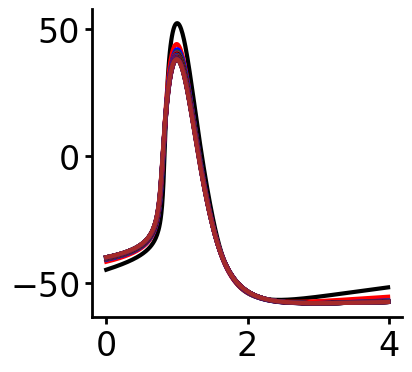

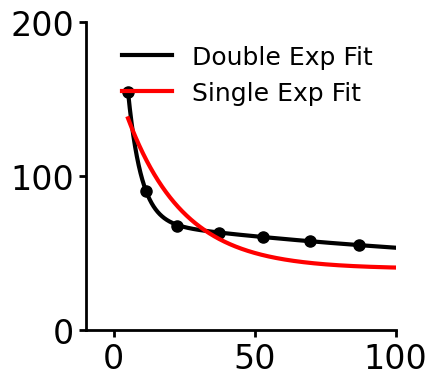

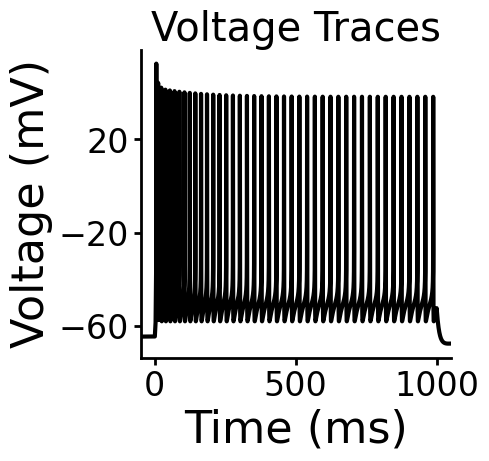

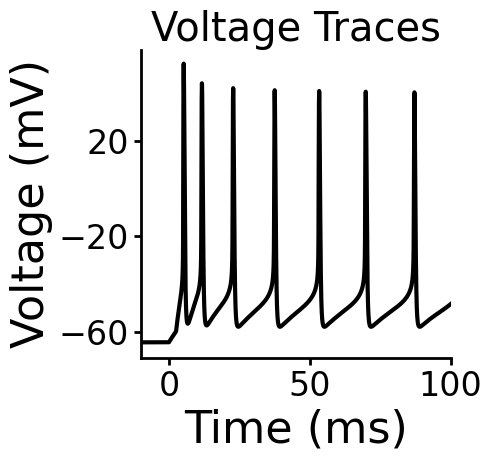

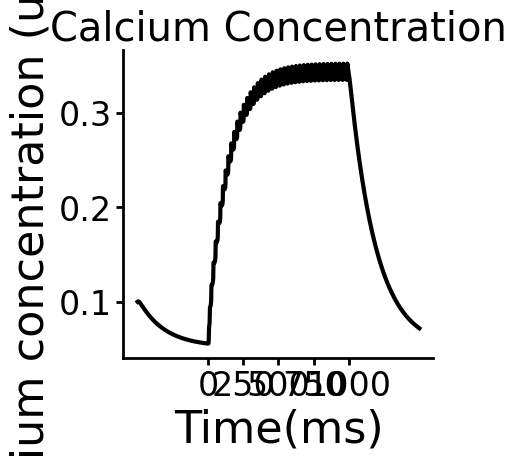

IAHP Aat the start of injection:  214.19145411 nA


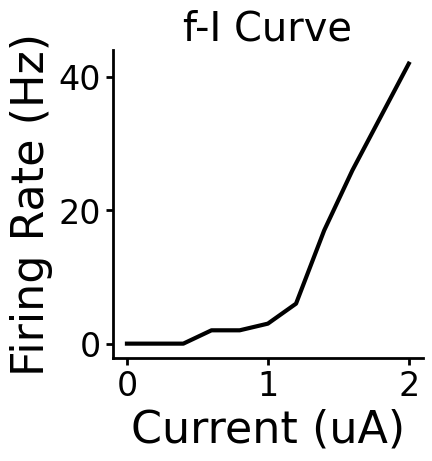

Plotting neurons [10]
Injected currents: [np.float64(2.0)] uA
Degree of Adaptation:  0.7597406952293524


In [6]:
current_values = np.linspace(init_current, max_injcurrent, num_injections)

# #Plot the Traces of an Adapting Neuron
model_params, sim_params = get_default_params()
sim_params['init_current'] = init_current
sim_params['num_neurons'] = num_injections
sim_params['max_injcurrent'] = max_injcurrent

neuron_indices = [num_injections - 1]#, 0]
state_monitor = HH_sim(model_params, sim_params)
M = state_monitor
e_info = get_ephys_properties(M.v/mV, M.t/ms, current_values, [sim_params['T_curr_on'], sim_params['T_curr_off']], \
                              plt_fit = True, curr_trace_idx = neuron_indices[0])
#state_monitor, e_info = HH_sim(model_params, sim_params)#, plt_fit = True, curr_trace_idx = curr_trace_idx)

## This part for debugging.
dAdap_info = e_info['dAdap_plot']
t_scatter = dAdap_info["t_scatter"]
OB_info= e_info['OB_plot']
y_de_fit = OB_info['fit_de']
# y_de_fit.params
y_se_fit= OB_info['fit_se']
# y_se_fit.params
all_currents = np.linspace(init_current, max_injcurrent, num_injections)
plot_fit(e_info,ymax=200,xmin=-10,xmax=100,fname="figures/")
#plot_fit(e_info,ymax=200,xmin=-500,xmax=1100,fname="figures/raw")
injected_currents = [round(current_values[idx], 2) for idx in neuron_indices]
plot_trace(state_monitor, neuron_indices, 
           injected_currents, sim_params['T_curr_on'] ,
           "figures/adapting_voltage_trace")
f_I(current_values, e_info['FR'])
print(f"Plotting neurons {neuron_indices}")
print(f"Injected currents: {injected_currents} uA")
print("Degree of Adaptation: ", e_info['dAdap'][neuron_indices[0]])

# Let's decrease the holding current to make neuron more depolarized

Starting simulation at t=0. s for a duration of 2. s
1.86189 s (93%) simulated in 10s, estimated 1s remaining.
2. s (100%) simulated in 10s


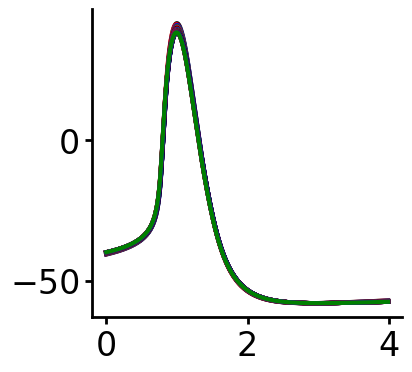

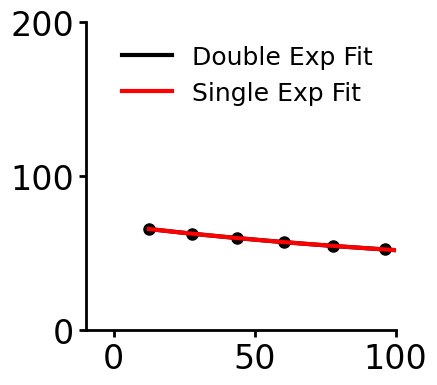

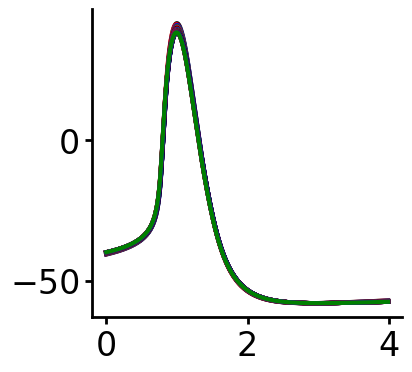

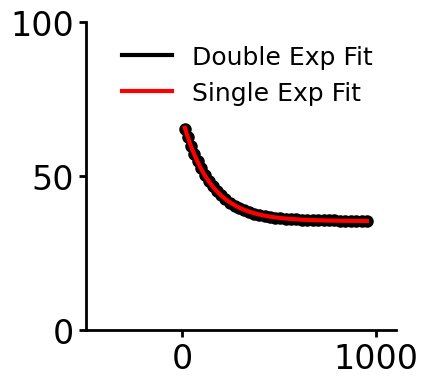

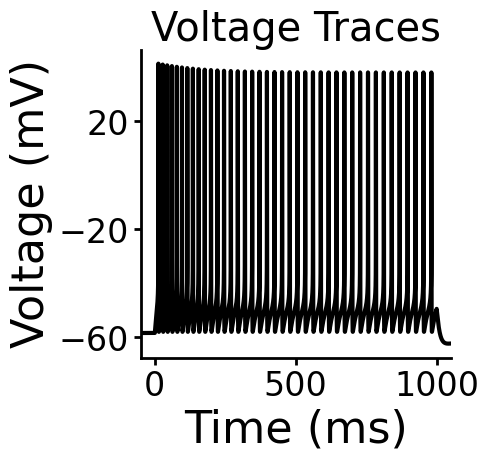

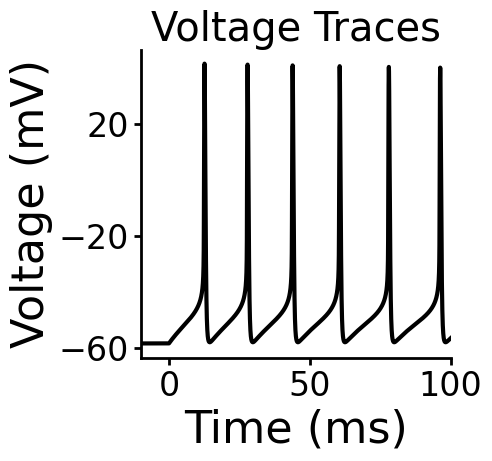

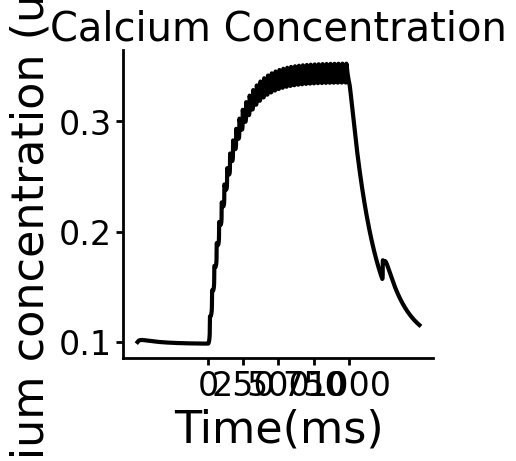

IAHP Aat the start of injection:  240.70897985 nA


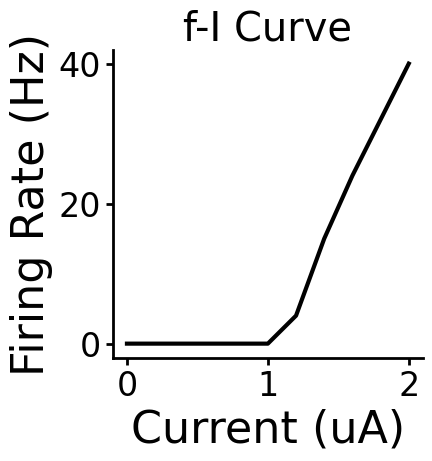

Plotting neurons [10]
Injected currents: [np.float64(2.0)] uA
Degree of Adaptation:  0.48199522396675787


In [7]:
current_values = np.linspace(init_current, max_injcurrent, num_injections)

# #Plot the Traces of an Adapting Neuron
model_params, sim_params = get_default_params()
shift_current = 0.6 #0.5 for the holding voltage being > -60mV

sim_params['hold_current'] = sim_params['hold_current'] + shift_current
sim_params['init_current'] = sim_params['init_current'] - shift_current
sim_params['max_injcurrent'] = sim_params['max_injcurrent'] - shift_current

neuron_indices = [num_injections - 1]#, 0]
state_monitor = HH_sim(model_params, sim_params)
M = state_monitor
e_info = get_ephys_properties(M.v/mV, M.t/ms, current_values, [sim_params['T_curr_on'], sim_params['T_curr_off']], \
                              plt_fit = True, curr_trace_idx = neuron_indices[0])
#state_monitor, e_info = HH_sim(model_params, sim_params)#, plt_fit = True, curr_trace_idx = curr_trace_idx)

all_currents = np.linspace(init_current, max_injcurrent, num_injections)
plot_fit(e_info,ymax=200,xmin=-10,xmax=100,fname="figures/depolarize_")
plot_fit(e_info,ymax=100,xmin=-500,xmax=1100,fname="figures/depolarize_raw")
injected_currents = [round(current_values[idx], 2) for idx in neuron_indices]
plot_trace(state_monitor, neuron_indices, 
           injected_currents, sim_params['T_curr_on'] ,
           "figures/adapting_voltage_trace_depolarized_holding")
f_I(current_values, e_info['FR'])
print(f"Plotting neurons {neuron_indices}")
print(f"Injected currents: {injected_currents} uA")
print("Degree of Adaptation: ", e_info['dAdap'][neuron_indices[0]])

# Change vary gT to see how dAdap will change

In [8]:
###This part might need some revision
gCaTs = np.linspace(0.00, 0.1, 11)
curr_trace_idx = num_injections -1

dAdap_arr_Ca = []
model_params, sim_params = get_default_params()
for gCaT_vary in gCaTs: 
    model_params['gCaT'] = gCaT_vary
    state_monitor = HH_sim(model_params, sim_params)
    e_info=get_ephys_properties(state_monitor.v/mV, state_monitor.t/ms, 
                                 current_values, [sim_params['T_curr_on'], 
                                 sim_params['T_curr_off']], 
                                 plt_fit = True,
                                 curr_trace_idx = curr_trace_idx)
    dAdap_arr_Ca.append(e_info['dAdap'][curr_trace_idx])
    print("Adaptation Index ", e_info['dAdap'][curr_trace_idx])
    
dAdap_arr_Ca_depolarized = []
model_params, sim_params = get_default_params()

shift_current = 0.6 #0.5 for the holding voltage being > -60mV
sim_params['hold_current'] = sim_params['hold_current'] + shift_current
sim_params['init_current'] = sim_params['init_current'] - shift_current
sim_params['max_injcurrent'] = sim_params['max_injcurrent'] - shift_current
for gCaT_vary in gCaTs: 
    model_params['gCaT'] = gCaT_vary
    state_monitor = HH_sim(model_params, sim_params)
    e_info=get_ephys_properties(state_monitor.v/mV, state_monitor.t/ms, 
                                 current_values, [sim_params['T_curr_on'], 
                                 sim_params['T_curr_off']], 
                                 plt_fit = True,
                                 curr_trace_idx = curr_trace_idx)
    dAdap_arr_Ca_depolarized.append(e_info['dAdap'][curr_trace_idx])
    print("Adaptation Index ", e_info['dAdap'][curr_trace_idx])
    

Starting simulation at t=0. s for a duration of 2. s
1.70949 s (85%) simulated in 10s, estimated 2s remaining.
2. s (100%) simulated in 11s
Adaptation Index  0.5237255544434101
Starting simulation at t=0. s for a duration of 2. s
1.41763 s (70%) simulated in 10s, estimated 4s remaining.
2. s (100%) simulated in 13s
Adaptation Index  0.5287240777918966
Starting simulation at t=0. s for a duration of 2. s
1.64946 s (82%) simulated in 10s, estimated 2s remaining.
2. s (100%) simulated in 12s
Adaptation Index  0.5543048451157901
Starting simulation at t=0. s for a duration of 2. s
1.59143 s (79%) simulated in 10s, estimated 3s remaining.
2. s (100%) simulated in 12s
Adaptation Index  0.6010548366216147
Starting simulation at t=0. s for a duration of 2. s
1.53055 s (76%) simulated in 10s, estimated 3s remaining.
2. s (100%) simulated in 12s
Adaptation Index  0.6725120244581773
Starting simulation at t=0. s for a duration of 2. s
1.56598 s (78%) simulated in 10s, estimated 3s remaining.
2. s

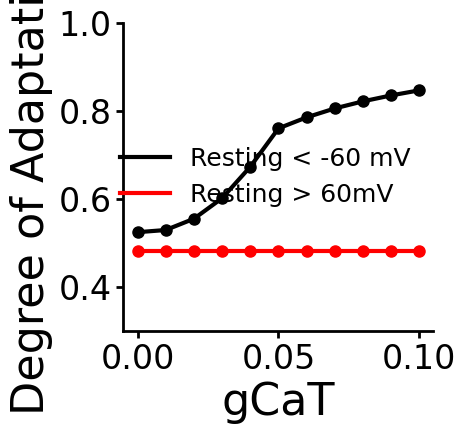

In [9]:
plt.figure()
plt.plot(gCaTs, dAdap_arr_Ca, label = "Resting < -60 mV", color = 'black')
plt.plot(gCaTs, dAdap_arr_Ca_depolarized, label = "Resting > 60mV", color = 'red')
plt.scatter(gCaTs, dAdap_arr_Ca, color = 'black')
plt.scatter(gCaTs, dAdap_arr_Ca_depolarized, color = 'red')
plt.xlabel("gCaT")
plt.ylabel("Degree of Adaptation")
plt.legend()
plt.ylim([0.3, 1])
plt.savefig('./figures/' + "dAdapoverT.svg")
plt.show()

# A proposed experiment: Changing gNa and gNa/gAHP to see their effects on spike-width and adaptation, with gK increased.

In [10]:
#Next run simulations for our proposed experiment
#Here, we will turn off gCaT
curr_trace_idx = num_injections -1

model_params2, sim_params = get_default_params()
model_params2['gK'] = 15
model_params2['gCaT'] = 0.0
state_monitor = HH_sim(model_params2, sim_params)#, plt_fit = False, curr_trace_idx = curr_trace_idx)
e_info2 = get_ephys_properties(state_monitor.v/mV, state_monitor.t/ms, 
                                 current_values, [sim_params['T_curr_on'], 
                                 sim_params['T_curr_off']], 
                                 plt_fit = True,
                                 curr_trace_idx = curr_trace_idx)

model_params3, _ = get_default_params()
model_params3['gK'] = 15
model_params3['gNa'] = 25
model_params3['gCaT'] = 0
state_monitor = HH_sim(model_params3, sim_params)#, plt_fit = False, curr_trace_idx = curr_trace_idx)
e_info3 = get_ephys_properties(state_monitor.v/mV, state_monitor.t/ms, 
                                 current_values, [sim_params['T_curr_on'], 
                                 sim_params['T_curr_off']], 
                                 plt_fit = True,
                                 curr_trace_idx = curr_trace_idx)

model_params4, _ = get_default_params()
model_params4['gK'] = 15
model_params4['gNa'] = 25
model_params4['gAhp'] = 2
model_params4['gCaT'] = 0.0
state_monitor = HH_sim(model_params4, sim_params)#, plt_fit = False, curr_trace_idx = curr_trace_idx)
e_info4 = get_ephys_properties(state_monitor.v/mV, state_monitor.t/ms, 
                                 current_values, [sim_params['T_curr_on'], 
                                 sim_params['T_curr_off']], 
                                 plt_fit = True,
                                 curr_trace_idx = curr_trace_idx)

Starting simulation at t=0. s for a duration of 2. s
1.86043 s (93%) simulated in 10s, estimated 1s remaining.
2. s (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 2. s
1.81099 s (90%) simulated in 10s, estimated 1s remaining.
2. s (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 2. s
1.8242 s (91%) simulated in 10s, estimated 1s remaining.
2. s (100%) simulated in 10s


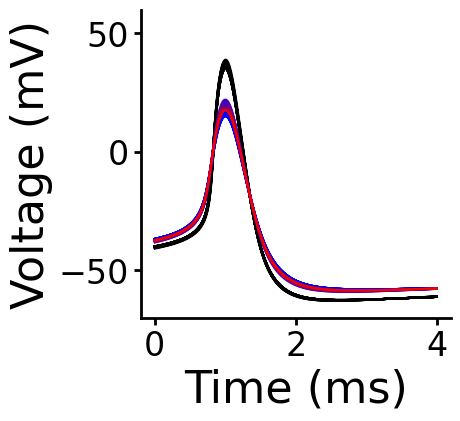

Spike Width for conditions:  [0.42095998 0.48454366 0.47696648]


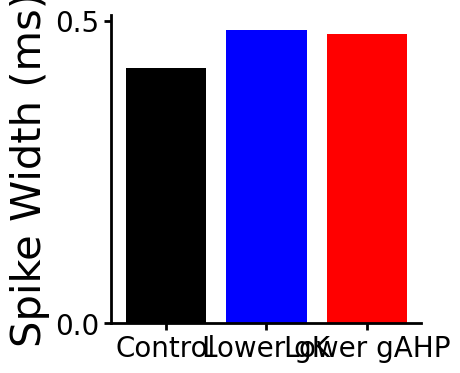

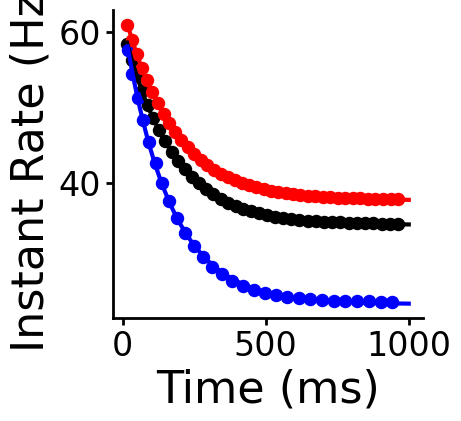

Degree of Adaptation for conditions:  [0.43274357 0.61250567 0.40411707]


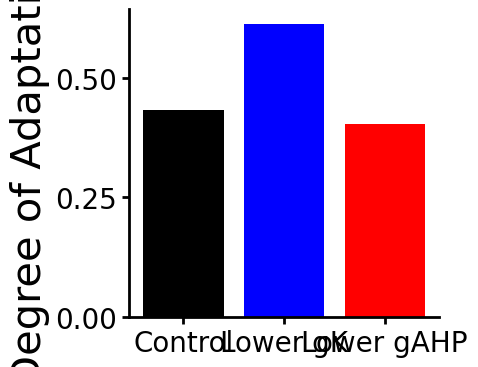

In [11]:
#Showing Fitting Procedure and results for proposed experiment
ephys_infos = [e_info2, e_info3, e_info4]
HW_barplt = np.zeros(len(ephys_infos))
dAdap_barplt = np.zeros(len(ephys_infos))

for i in range(len(ephys_infos)): 
    curr_ind = ephys_infos[i]['rheobase_ind'] #Current that produces rheobase 
    HW_barplt[i] = ephys_infos[i]['HW'][curr_trace_idx]
    dAdap_barplt[i] = ephys_infos[i]['dAdap'][curr_trace_idx]
line_colors = ['black', 'blue', 'red']
alphas = [1, 1, 0.1]
linewidths = [1.5, 1.5, 1.5]
plt.figure()

for i in range(len(ephys_infos)): 
    HW_info = ephys_infos[i]['HW_plot']
    AP_waveform = HW_info['APwaveform']
    dtstep = HW_info['dtstep']
    
    for sweep in range(len(AP_waveform)): 
        plt.plot(np.arange(len(AP_waveform[sweep]))*dtstep, AP_waveform[sweep], color = line_colors[i], \
                 linewidth = linewidths[i], alpha = alphas[i])
plt.locator_params(axis = 'y', nbins = 3)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.ylim([-70, 60])
plt.savefig("figures/HW_fit.svg")
plt.show()

labels = ["Control", "Lower gK", "Lower gAHP"]
print("Spike Width for conditions: ", HW_barplt)
plt.figure()
plt.bar(labels, HW_barplt, color = line_colors)
plt.locator_params(axis = 'y', nbins = 2)
plt.ylabel("Spike Width (ms)", fontsize = 30)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.savefig("figures/HW_barplt.svg")
plt.show()

plt.figure()
for i in range(len(ephys_infos)):
    dAdap_info = ephys_infos[i]['dAdap_plot']
    t_scatter = dAdap_info["t_scatter"]
    FI_scatter = dAdap_info["FI_scatter"]
    t_axis = dAdap_info["t_axis"]
    y_fit = dAdap_info["y_fit"]
    
    
    idx_aftersample = np.where(t_axis > t_scatter[0])
    plt.scatter(t_scatter, FI_scatter, color = line_colors[i], s = 75)
    plt.plot(t_axis[idx_aftersample], y_fit[idx_aftersample], color = line_colors[i], linewidth = 3)
plt.locator_params(axis = 'y', nbins = 3)
plt.xlabel("Time (ms)")
plt.ylabel("Instant Rate (Hz)")
plt.savefig("figures/dAdap_fit.svg")
plt.show()

labels = ["Control", "Lower gK", "Lower gAHP"]
plt.figure()
print("Degree of Adaptation for conditions: ", dAdap_barplt)
plt.bar(labels, dAdap_barplt, color = line_colors)
plt.locator_params(axis = 'y', nbins = 3)
plt.ylabel("Degree of Adaptation", fontsize = 30)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.savefig("figures/dAdap_barplt.svg")
plt.show()

In [ ]:
# Including the original experiment based on TEA.

In [12]:
#Next run simulations for our proposed experiment, with more g
#Here, we will turn off gCaT
curr_trace_idx = num_injections -1

model_params2, sim_params = get_default_params()
model_params2['gK'] = 15
model_params2['gCaT'] = 0.0
state_monitor = HH_sim(model_params2, sim_params)#, plt_fit = False, curr_trace_idx = curr_trace_idx)
e_info2 = get_ephys_properties(state_monitor.v/mV, state_monitor.t/ms, 
                                 current_values, [sim_params['T_curr_on'], 
                                 sim_params['T_curr_off']], 
                                 plt_fit = True,
                                 curr_trace_idx = curr_trace_idx)

model_params3, _ = get_default_params()
model_params3['gK'] = 5
model_params3['gCaT'] = 0
state_monitor = HH_sim(model_params3, sim_params)#, plt_fit = False, curr_trace_idx = curr_trace_idx)
e_info3 = get_ephys_properties(state_monitor.v/mV, state_monitor.t/ms, 
                                 current_values, [sim_params['T_curr_on'], 
                                 sim_params['T_curr_off']], 
                                 plt_fit = True,
                                 curr_trace_idx = curr_trace_idx)

model_params4, _ = get_default_params()
model_params4['gK'] = 5
model_params4['gAhp'] = 2
model_params4['gCaT'] = 0.0
state_monitor = HH_sim(model_params4, sim_params)#, plt_fit = False, curr_trace_idx = curr_trace_idx)
e_info4 = get_ephys_properties(state_monitor.v/mV, state_monitor.t/ms, 
                                 current_values, [sim_params['T_curr_on'], 
                                 sim_params['T_curr_off']], 
                                 plt_fit = True,
                                 curr_trace_idx = curr_trace_idx)

WARNING    'i' is an internal variable of group 'neurongroup_2', but also exists in the run namespace with the value 2. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Starting simulation at t=0. s for a duration of 2. s
1.75464 s (87%) simulated in 10s, estimated 1s remaining.
2. s (100%) simulated in 11s


WARNING    'i' is an internal variable of group 'neurongroup', but also exists in the run namespace with the value 2. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Starting simulation at t=0. s for a duration of 2. s
1.82459 s (91%) simulated in 10s, estimated 1s remaining.
2. s (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 2. s
1.67957 s (83%) simulated in 10s, estimated 2s remaining.
2. s (100%) simulated in 12s


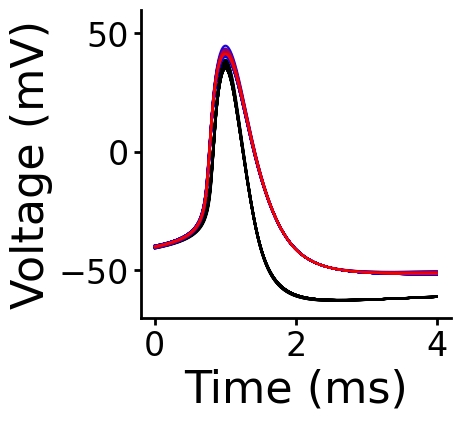

Spike Width for conditions:  [0.42095998 0.60532568 0.60382948]


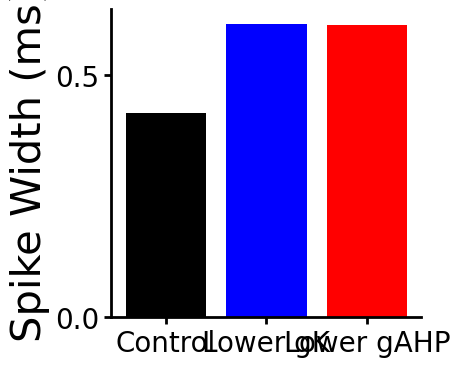

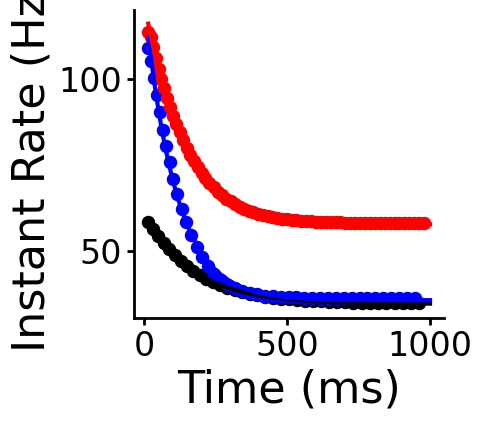

Degree of Adaptation for conditions:  [0.43274357 0.71201599 0.52946855]


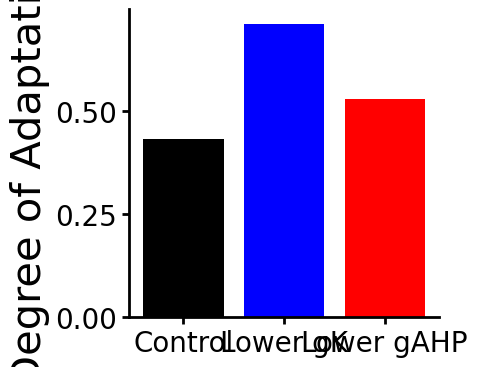

In [14]:
#Showing Fitting Procedure and results for proposed experiment
ephys_infos = [e_info2, e_info3, e_info4]
HW_barplt = np.zeros(len(ephys_infos))
dAdap_barplt = np.zeros(len(ephys_infos))

for i in range(len(ephys_infos)): 
    curr_ind = ephys_infos[i]['rheobase_ind'] #Current that produces rheobase 
    HW_barplt[i] = ephys_infos[i]['HW'][curr_trace_idx]
    dAdap_barplt[i] = ephys_infos[i]['dAdap'][curr_trace_idx]
line_colors = ['black', 'blue', 'red']
alphas = [1, 1, 0.1]
linewidths = [1.5, 1.5, 1.5]
plt.figure()

for i in range(len(ephys_infos)): 
    HW_info = ephys_infos[i]['HW_plot']
    AP_waveform = HW_info['APwaveform']
    dtstep = HW_info['dtstep']
    
    for sweep in range(len(AP_waveform)): 
        plt.plot(np.arange(len(AP_waveform[sweep]))*dtstep, AP_waveform[sweep], color = line_colors[i], \
                 linewidth = linewidths[i], alpha = alphas[i])
plt.locator_params(axis = 'y', nbins = 3)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.ylim([-70, 60])
plt.savefig("figures/K_HW_fit.svg")
plt.show()

labels = ["Control", "Lower gK", "Lower gAHP"]
print("Spike Width for conditions: ", HW_barplt)
plt.figure()
plt.bar(labels, HW_barplt, color = line_colors)
plt.locator_params(axis = 'y', nbins = 2)
plt.ylabel("Spike Width (ms)", fontsize = 30)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.savefig("figures/K_HW_barplt.svg")
plt.show()

plt.figure()
for i in range(len(ephys_infos)):
    dAdap_info = ephys_infos[i]['dAdap_plot']
    t_scatter = dAdap_info["t_scatter"]
    FI_scatter = dAdap_info["FI_scatter"]
    t_axis = dAdap_info["t_axis"]
    y_fit = dAdap_info["y_fit"]
    
    
    idx_aftersample = np.where(t_axis > t_scatter[0])
    plt.scatter(t_scatter, FI_scatter, color = line_colors[i], s = 75)
    plt.plot(t_axis[idx_aftersample], y_fit[idx_aftersample], color = line_colors[i], linewidth = 3)
plt.locator_params(axis = 'y', nbins = 3)
plt.xlabel("Time (ms)")
plt.ylabel("Instant Rate (Hz)")
plt.savefig("figures/K_dAdap_fit.svg")
plt.show()

labels = ["Control", "Lower gK", "Lower gAHP"]
plt.figure()
print("Degree of Adaptation for conditions: ", dAdap_barplt)
plt.bar(labels, dAdap_barplt, color = line_colors)
plt.locator_params(axis = 'y', nbins = 3)
plt.ylabel("Degree of Adaptation", fontsize = 30)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.savefig("figures/K_dAdap_barplt.svg")
plt.show()

In [15]:
#Parameter space for gK and gCa
caL_arr = [0.05, 0.06, 0.07,0.08,0.09, 0.1, 0.11, 0.12, 0.13, 0.14,0.15]
k_arr = [5, 6,7,8, 9, 10,11, 12,13, 14, 15]

cak_hw_param_space = np.zeros((len(caL_arr), len(k_arr)))
cak_dAdap_param_space = np.zeros((len(caL_arr), len(k_arr)))

for i in range(len(caL_arr)): 
    for j in range(len(k_arr)): 
        model_params, sim_params = get_default_params()
        g_CaL = caL_arr[i]
        g_k = k_arr[j]
        model_params['gCaL'] = g_CaL
        model_params['gK'] = g_k
        model_params['gCaT'] = 0
        state_monitor = HH_sim(model_params, sim_params)#, plt_fit = False, curr_trace_idx = curr_trace_idx)
        
        e_info = get_ephys_properties(state_monitor.v/mV, state_monitor.t/ms, 
                                 current_values, [sim_params['T_curr_on'], 
                                 sim_params['T_curr_off']], 
                                 plt_fit = True,
                                 curr_trace_idx = curr_trace_idx)

        cak_hw_param_space[i, j] = e_info['HW'][curr_trace_idx] 
        cak_dAdap_param_space[i, j] = e_info['dAdap'][curr_trace_idx]


WARNING    'i' is an internal variable of group 'neurongroup', but also exists in the run namespace with the value 0. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Starting simulation at t=0. s for a duration of 2. s
1.91928 s (95%) simulated in 10s, estimated < 1s remaining.
2. s (100%) simulated in 10s


WARNING    'i' is an internal variable of group 'neurongroup_2', but also exists in the run namespace with the value 0. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Starting simulation at t=0. s for a duration of 2. s
1.87331 s (93%) simulated in 10s, estimated 1s remaining.
2. s (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 2. s
1.82173 s (91%) simulated in 10s, estimated 1s remaining.
2. s (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 2. s
1.89189 s (94%) simulated in 10s, estimated 1s remaining.
2. s (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 2. s
1.89694 s (94%) simulated in 10s, estimated 1s remaining.
2. s (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 2. s
1.83099 s (91%) simulated in 10s, estimated 1s remaining.
2. s (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 2. s
1.47745 s (73%) simulated in 10s, estimated 4s remaining.
2. s (100%) simulated in 13s
Starting simulation at t=0. s for a duration of 2. s
1.76704 s (88%) simulated in 10s, estimated 1s remaining.
2. s (100%) simulated in 11s
Starting simulation 

WARNING    'i' is an internal variable of group 'neurongroup_2', but also exists in the run namespace with the value 1. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


...

WARNING    'i' is an internal variable of group 'neurongroup', but also exists in the run namespace with the value 10. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Starting simulation at t=0. s for a duration of 2. s
1.59471 s (79%) simulated in 10s, estimated 3s remaining.
2. s (100%) simulated in 12s


WARNING    'i' is an internal variable of group 'neurongroup_2', but also exists in the run namespace with the value 10. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Starting simulation at t=0. s for a duration of 2. s
1.61586 s (80%) simulated in 10s, estimated 2s remaining.
2. s (100%) simulated in 12s
Starting simulation at t=0. s for a duration of 2. s
1.63599 s (81%) simulated in 10s, estimated 2s remaining.
2. s (100%) simulated in 12s
Starting simulation at t=0. s for a duration of 2. s
1.63106 s (81%) simulated in 10s, estimated 2s remaining.
2. s (100%) simulated in 12s
Starting simulation at t=0. s for a duration of 2. s
1.67306 s (83%) simulated in 10s, estimated 2s remaining.
2. s (100%) simulated in 11s
Starting simulation at t=0. s for a duration of 2. s
1.65033 s (82%) simulated in 10s, estimated 2s remaining.
2. s (100%) simulated in 12s
Starting simulation at t=0. s for a duration of 2. s
1.61546 s (80%) simulated in 10s, estimated 2s remaining.
2. s (100%) simulated in 12s
Starting simulation at t=0. s for a duration of 2. s
1.2121 s (60%) simulated in 10s, estimated 7s remaining.
2. s (100%) simulated in 15s
Starting simulation a

1.81137 s (90%) simulated in 20s, estimated 2s remaining.
2. s (100%) simulated in 21s
Starting simulation at t=0. s for a duration of 2. s
0.88194 s (44%) simulated in 10s, estimated 13s remaining.
1.79638 s (89%) simulated in 20s, estimated 2s remaining.
2. s (100%) simulated in 22s
Starting simulation at t=0. s for a duration of 2. s
0.68284 s (34%) simulated in 10s, estimated 19s remaining.
1.50544 s (75%) simulated in 20s, estimated 7s remaining.
2. s (100%) simulated in 25s
Starting simulation at t=0. s for a duration of 2. s
0.91389 s (45%) simulated in 10s, estimated 12s remaining.
1.92479 s (96%) simulated in 20s, estimated 1s remaining.
2. s (100%) simulated in 20s
Starting simulation at t=0. s for a duration of 2. s
0.9723 s (48%) simulated in 10s, estimated 11s remaining.
1.89502 s (94%) simulated in 20s, estimated 1s remaining.
2. s (100%) simulated in 21s
Starting simulation at t=0. s for a duration of 2. s
0.92886 s (46%) simulated in 10s, estimated 12s remaining.
1.8315

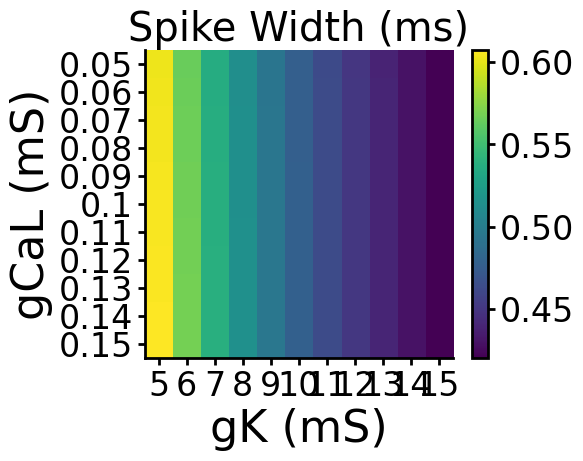

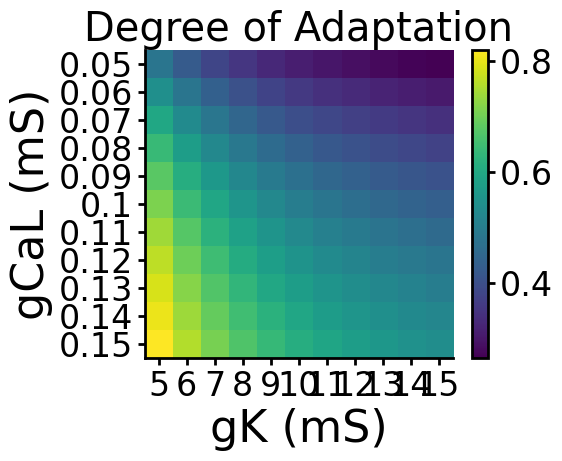

In [18]:
#Plot Heatmap
info_cak_ahp = {"x_param": "gK (mS)", 
              "y_param": "gCaL (mS)"}

fname = "figures/cak_hw_heatmap.svg"
info_cak_ahp['title'] = "Spike Width (ms)"
make_heatmap(cak_hw_param_space, k_arr, caL_arr, info_cak_ahp, fname)

fname = "figures/cak_dAdap_heatmap.svg"
info_cak_ahp['title'] = "Degree of Adaptation"
make_heatmap(cak_dAdap_param_space, k_arr, caL_arr, info_cak_ahp, fname)

In [36]:
#Create variable parameters for gNa, gK, and gCa to examine correlations between HW and dAdap
corr_na_k = 0.1
corr_na_ca = -0.15
corr_k_ca = -0.15
num_samples = 300
g_means = [35, 9, 0.15] 
g_std = np.diag(np.sqrt([5, 8, 0.01]))
corr = np.array([[1, corr_na_k, corr_na_ca], 
         [corr_na_k, 1, corr_k_ca], 
         [corr_na_ca, corr_k_ca, 1]])
covar = g_std @ corr @ g_std

# Sample with rejection for positive values
g_samples = []
while len(g_samples) < num_samples:
    # Calculate how many more samples we need
    remaining = num_samples - len(g_samples)
    # Sample extra to account for potential rejections
    batch_size = remaining + 100
    
    batch = np.random.multivariate_normal(g_means, covar, batch_size)
    
    # Keep only samples where all values are positive (especially gCaL)
    valid_samples = batch[(batch[:, 0] > 0) & (batch[:, 1] > 0) & (batch[:, 2] > 0)]
    g_samples.extend(valid_samples)

# Convert to array and take only the number of samples we need
g_samples = np.array(g_samples[:num_samples]).T
g_na, g_k, g_ca = g_samples[0], g_samples[1], g_samples[2]

hw_arr = np.zeros(len(g_na))
dAdap_arr = np.zeros(len(g_na))

print(g_na, g_k, g_ca)
for g in range(len(g_na)): 
    print("Now running simulation #", g)
    gNa = g_na[g]
    gK = g_k[g]
    gCaL = g_ca[g]
    
    model_params, sim_params = get_default_params()
    model_params['gNa'] = gNa
    model_params['gK'] = gK
    model_params['gCaL'] = gCaL
    
    
    state_monitor = HH_sim(model_params, sim_params)
    
    e_info = get_ephys_properties(state_monitor.v/mV, state_monitor.t/ms, 
                                 current_values, [sim_params['T_curr_on'], 
                                 sim_params['T_curr_off']], 
                                 plt_fit = True,
                                 curr_trace_idx = curr_trace_idx)

    #curr_ind = e_info['rheobase_ind'] #Current that produces rheobase 
    hw_arr[g] = e_info['HW'][curr_trace_idx] 
    dAdap_arr[g] = e_info['dAdap'][curr_trace_idx]
    print("Half Width: ", hw_arr[g])
    print("Adaptation Index: ", dAdap_arr[g])

[36.84736392 38.64434116 31.59581295 36.51130217 35.30741475 33.90362346
 36.43181038 36.11874807 36.8407967  31.92468592 32.77029803 33.68131259
 36.16154678 34.05177322 35.41311478 36.28059198 32.75898874 39.20657621
 32.76280125 39.49174029 32.04187982 31.39661996 37.15505263 33.94245691
 33.14873034 35.91032724 34.23520046 31.64355892 32.80413028 33.48737084
 32.40536643 31.06145367 37.68132941 33.40142174 35.78201297 35.44876134
 32.98069024 36.13816187 35.36926981 33.73856987 32.13440786 35.29666318
 34.34745553 39.73680048 34.65742166 34.26723078 33.5799187  40.69193799
 36.51355307 35.78113303 33.52703356 35.9395031  37.79671961 36.62943617
 33.75076112 33.40479858 37.53962429 32.18649979 36.50917041 34.64051503
 37.17854461 33.3809443  34.71596349 34.41809628 35.6585748  34.18798551
 31.35433151 34.04720464 37.61781697 31.49822686 30.74679104 39.91763719
 32.96503815 37.08478016 37.17182069 35.5252882  34.37061443 36.55060584
 35.60728559 33.43629513 32.89258649 34.9718985  34

Starting simulation at t=0. s for a duration of 2. s
0.78471 s (39%) simulated in 10s, estimated 15s remaining.
1.49479 s (74%) simulated in 20s, estimated 7s remaining.
2. s (100%) simulated in 26s
Half Width:  0.4954101422646667
Adaptation Index:  0.8455035299838545
Now running simulation # 1
Starting simulation at t=0. s for a duration of 2. s
0.73575 s (36%) simulated in 10s, estimated 17s remaining.
1.45753 s (72%) simulated in 20s, estimated 7s remaining.
2. s (100%) simulated in 27s
Half Width:  0.5487250495503334
Adaptation Index:  0.930231904326737
Now running simulation # 2
Starting simulation at t=0. s for a duration of 2. s
0.76439 s (38%) simulated in 10s, estimated 16s remaining.
1.53069 s (76%) simulated in 20s, estimated 6s remaining.
2. s (100%) simulated in 25s
Half Width:  0.4518677094464437
Adaptation Index:  0.22431999624584997
Now running simulation # 3
Starting simulation at t=0. s for a duration of 2. s
0.63851 s (31%) simulated in 10s, estimated 21s remaining.


0.53282 s (26%) simulated in 20s, estimated 55s remaining.
0.8109 s (40%) simulated in 30s, estimated 44s remaining.
1.25604 s (62%) simulated in 40s, estimated 24s remaining.
1.63124 s (81%) simulated in 50s, estimated 11s remaining.
1.928 s (96%) simulated in 1m 0s, estimated 2s remaining.
2. s (100%) simulated in 1m 1s
Half Width:  0.5060613175595198
Adaptation Index:  0.266156705706335
Now running simulation # 26
Starting simulation at t=0. s for a duration of 2. s
0.57117 s (28%) simulated in 10s, estimated 25s remaining.
1.17425 s (58%) simulated in 20s, estimated 14s remaining.
1.79161 s (89%) simulated in 30s, estimated 3s remaining.
2. s (100%) simulated in 34s
Half Width:  0.6977748436821247
Adaptation Index:  0.8139761198634418
Now running simulation # 27
Starting simulation at t=0. s for a duration of 2. s
0.6539 s (32%) simulated in 10s, estimated 21s remaining.
1.15677 s (57%) simulated in 20s, estimated 15s remaining.
1.60187 s (80%) simulated in 30s, estimated 7s remain

1.58927 s (79%) simulated in 20s, estimated 5s remaining.
2. s (100%) simulated in 25s
Half Width:  0.0
Adaptation Index:  0.0
Now running simulation # 48
Starting simulation at t=0. s for a duration of 2. s
0.79977 s (39%) simulated in 10s, estimated 15s remaining.
1.61427 s (80%) simulated in 20s, estimated 5s remaining.
2. s (100%) simulated in 24s
Half Width:  0.46084521391008426
Adaptation Index:  0.7711581600165022
Now running simulation # 49
Starting simulation at t=0. s for a duration of 2. s
0.75144 s (37%) simulated in 10s, estimated 17s remaining.
1.4916 s (74%) simulated in 20s, estimated 7s remaining.
2. s (100%) simulated in 26s
Half Width:  0.4594177442976704
Adaptation Index:  0.8763934725177747
Now running simulation # 50
Starting simulation at t=0. s for a duration of 2. s
0.87559 s (43%) simulated in 10s, estimated 13s remaining.
1.70371 s (85%) simulated in 20s, estimated 3s remaining.
2. s (100%) simulated in 24s
Half Width:  0.6671900104024282
Adaptation Index:  0

1.7744 s (88%) simulated in 20s, estimated 3s remaining.
2. s (100%) simulated in 22s
Half Width:  0.599879278770493
Adaptation Index:  0.9490668699372318
Now running simulation # 73
Starting simulation at t=0. s for a duration of 2. s
0.70915 s (35%) simulated in 10s, estimated 18s remaining.
1.39243 s (69%) simulated in 20s, estimated 9s remaining.
2. s (100%) simulated in 28s
Half Width:  0.44370218120463356
Adaptation Index:  0.8047129285447785
Now running simulation # 74
Starting simulation at t=0. s for a duration of 2. s
0.71248 s (35%) simulated in 10s, estimated 18s remaining.
1.43575 s (71%) simulated in 20s, estimated 8s remaining.
2. s (100%) simulated in 27s
Half Width:  0.4889210650506723
Adaptation Index:  0.659582640014184
Now running simulation # 75
Starting simulation at t=0. s for a duration of 2. s
0.83272 s (41%) simulated in 10s, estimated 14s remaining.
1.67975 s (83%) simulated in 20s, estimated 4s remaining.
2. s (100%) simulated in 23s
Half Width:  0.492930820

...

Half Width:  0.48550243255513087
Adaptation Index:  0.8483072778477567
Now running simulation # 173
Starting simulation at t=0. s for a duration of 2. s
0.81683 s (40%) simulated in 10s, estimated 14s remaining.
1.71059 s (85%) simulated in 20s, estimated 3s remaining.
2. s (100%) simulated in 22s
Half Width:  0.5457004550455423
Adaptation Index:  0.737753164645536
Now running simulation # 174
Starting simulation at t=0. s for a duration of 2. s
0.88128 s (44%) simulated in 10s, estimated 13s remaining.
1.55407 s (77%) simulated in 20s, estimated 6s remaining.
2. s (100%) simulated in 25s
Half Width:  0.5256613951979214
Adaptation Index:  0.7165738852117394
Now running simulation # 175
Starting simulation at t=0. s for a duration of 2. s
0.77406 s (38%) simulated in 10s, estimated 16s remaining.
1.34618 s (67%) simulated in 20s, estimated 10s remaining.
1.87648 s (93%) simulated in 30s, estimated 2s remaining.
2. s (100%) simulated in 32s
Half Width:  0.4877512041363769
Adaptation Inde

Starting simulation at t=0. s for a duration of 2. s
0.72908 s (36%) simulated in 10s, estimated 17s remaining.
1.52263 s (76%) simulated in 20s, estimated 6s remaining.
2. s (100%) simulated in 25s
Half Width:  0.512170027320949
Adaptation Index:  0.8007006453762281
Now running simulation # 200
Starting simulation at t=0. s for a duration of 2. s
0.85041 s (42%) simulated in 10s, estimated 14s remaining.
1.57891 s (78%) simulated in 20s, estimated 5s remaining.
2. s (100%) simulated in 25s
Half Width:  0.49095244175317904
Adaptation Index:  0.8595647990709661
Now running simulation # 201
Starting simulation at t=0. s for a duration of 2. s
0.81163 s (40%) simulated in 10s, estimated 15s remaining.
1.76121 s (88%) simulated in 20s, estimated 3s remaining.
2. s (100%) simulated in 22s
Half Width:  0.5520788150617966
Adaptation Index:  0.753616938469281
Now running simulation # 202
Starting simulation at t=0. s for a duration of 2. s
0.89919 s (44%) simulated in 10s, estimated 12s remain

1.33423 s (66%) simulated in 20s, estimated 10s remaining.
2. s (100%) simulated in 29s
Half Width:  0.5797314533507644
Adaptation Index:  0.3567949419919729
Now running simulation # 226
Starting simulation at t=0. s for a duration of 2. s
0.55308 s (27%) simulated in 10s, estimated 26s remaining.
1.05926 s (52%) simulated in 20s, estimated 18s remaining.
1.57424 s (78%) simulated in 30s, estimated 8s remaining.
2. s (100%) simulated in 38s
Half Width:  0.46796717463937193
Adaptation Index:  0.2436738172492049
Now running simulation # 227
Starting simulation at t=0. s for a duration of 2. s
0.76814 s (38%) simulated in 10s, estimated 16s remaining.
1.3806 s (69%) simulated in 20s, estimated 9s remaining.
1.93717 s (96%) simulated in 30s, estimated 1s remaining.
2. s (100%) simulated in 31s
Half Width:  0.5049506447255091
Adaptation Index:  0.7668301799693822
Now running simulation # 228
Starting simulation at t=0. s for a duration of 2. s
0.4766 s (23%) simulated in 10s, estimated 32s 

1.60188 s (80%) simulated in 30s, estimated 7s remaining.
2. s (100%) simulated in 37s
Half Width:  0.4902961988703892
Adaptation Index:  0.45231814757059485
Now running simulation # 251
Starting simulation at t=0. s for a duration of 2. s
0.48351 s (24%) simulated in 10s, estimated 31s remaining.
0.93911 s (46%) simulated in 20s, estimated 23s remaining.
1.16124 s (58%) simulated in 30s, estimated 22s remaining.
1.42433 s (71%) simulated in 40s, estimated 16s remaining.
1.86353 s (93%) simulated in 50s, estimated 4s remaining.
2. s (100%) simulated in 52s
Half Width:  0.5479495154970804
Adaptation Index:  0.7598398320561698
Now running simulation # 252
Starting simulation at t=0. s for a duration of 2. s
0.65029 s (32%) simulated in 10s, estimated 21s remaining.
1.43984 s (71%) simulated in 20s, estimated 8s remaining.
2. s (100%) simulated in 27s
Half Width:  0.551140433862188
Adaptation Index:  0.9118221649989637
Now running simulation # 253
Starting simulation at t=0. s for a durat

2. s (100%) simulated in 26s
Half Width:  0.4178714450688537
Adaptation Index:  0.5430516630516307
Now running simulation # 277
Starting simulation at t=0. s for a duration of 2. s
0.6714 s (33%) simulated in 10s, estimated 20s remaining.
1.38611 s (69%) simulated in 20s, estimated 9s remaining.
2. s (100%) simulated in 29s
Half Width:  0.5018221324158088
Adaptation Index:  0.7459097696801241
Now running simulation # 278
Starting simulation at t=0. s for a duration of 2. s
0.69389 s (34%) simulated in 10s, estimated 19s remaining.
1.45007 s (72%) simulated in 20s, estimated 8s remaining.
2. s (100%) simulated in 27s
Half Width:  0.5044917363822673
Adaptation Index:  0.8770883287886374
Now running simulation # 279
Starting simulation at t=0. s for a duration of 2. s
0.73694 s (36%) simulated in 10s, estimated 17s remaining.
1.43302 s (71%) simulated in 20s, estimated 8s remaining.
2. s (100%) simulated in 28s
Half Width:  0.4729726667858308
Adaptation Index:  0.6372566452483468
Now runn

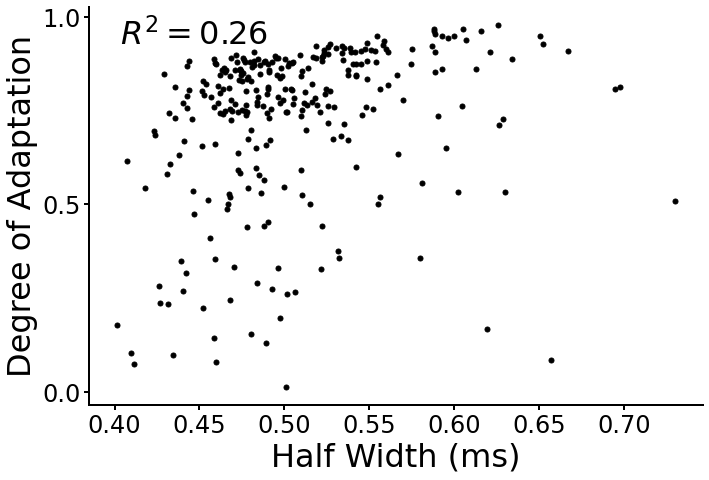

In [39]:
#Only take values where there are sufficient number of spikes and fitting worked (e.g. dAdap > 0)
subset = (dAdap_arr > 0)

#Plot Correlations and decision boundary
r_squared = np.corrcoef(hw_arr[subset], dAdap_arr[subset])[0, 1]
fname = "figures/HWdAdap_corrplot.svg"
plt.figure()
plt.scatter(hw_arr[subset], dAdap_arr[subset], s = 25)
plt.xlabel("Half Width (ms)")
plt.ylabel("Degree of Adaptation")
plt.locator_params(axis = 'y', nbins = 3)
plt.text(0.05, 0.975, f'$R^2 = {r_squared:.2f}$', transform=plt.gca().transAxes, verticalalignment='top')
plt.savefig(fname)
plt.show()